# 多重比較検定をしてみよう①Turkey検定

In [ ]:
#Turkey検定のコードです。
import pandas as pd
import io
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# 1. Excelからコピーしたデータをここに貼り付ける（例：3列分）
# ※ 以下の三連引用符の中に、Excelの列（タイトル行含む）をコピペしてください
csv_data = """
1980	1988	2025
20.8	28.5	26.7
20.2	28.7	29.6
18.8	29.4	30.8
19.6	30	31.8
21.4	30	33.1
20.8	29.9	31.7
21.6	28.9	28.5
20.3	28.1	28.2
21.4	30	28.3
22.2	30	25.8
23.5	31.5	27.2
25.1	31.2	27.9
26.1	30.8	27.6
27.5	30.4	28
27.3	30.3	28.7
20.9	26.7	29.3
23.7	30.4	30.4
24.8	29.7	29.8
24.9	29.2	29.7
23.2	28.3	30.6
23.8	28.3	29.6
22.6	27.5	29.9
23.5	28.9	30.7
25.9	29.4	31.5
23.4	28.6	30.5
18.9	29.2	30.6
19	27.7	30.3
22.8	28	28.4
23.3	27.1	28.9
24.3	26	31.4
23.2	27.1	31
""" # ← 赤文字を消して、ここに実際のデータを貼り付け！

# 2. データの読み込みと整形
df = pd.read_csv(io.StringIO(csv_data.strip()), sep='\t')
df_melted = df.melt(var_name='Year', value_name='Temp').dropna()

# 3. Tukeyの多重比較を実行
tukey = pairwise_tukeyhsd(endog=df_melted['Temp'],     # データの値
                          groups=df_melted['Year'],    # グループ分け
                          alpha=0.05)                  # 有意水準

# 4. 結果の表示
print(tukey)

# 5. 結果をグラフで確認（どのペアに差があるか視覚化）
tukey.plot_simultaneous()
plt.vlines(x=df_melted['Temp'].mean(), ymin=-0.5, ymax=len(df.columns)-0.5, color='red', linestyle='--')
plt.show()

# 6. 最後にちょっと見やすい検定結果を追加。
df_results = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
display(df_results)

# 多重比較検定をしてみよう②Dunnett検定

--- Dunnett Test Results (Control: 1980) ---
Dunnett's test (95.0% Confidence Interval)
Comparison               Statistic  p-value  Lower CI  Upper CI
 (Sample 0 - Control)     13.436     0.000     5.238     7.342
 (Sample 1 - Control)     14.586     0.000     5.777     7.881



<Figure size 800x600 with 0 Axes>

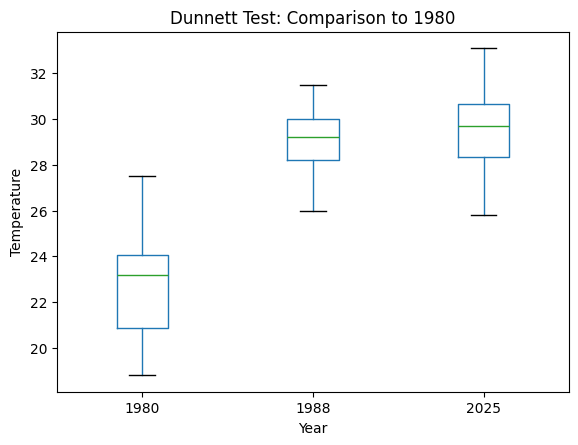

,Comparison,P-value,Statistic
0,1980 vs 1988,0.0,13.435523
1,1980 vs 2025,0.0,14.586155


In [13]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import io  # これを忘れると StringIO でエラーが出ます！

# 1. Excelからコピーしたデータをここに貼り付ける
csv_data = """
year1	year2	year3
data1 data2 data3
"""

# 2. データの読み込みと整形
# sep='\s+' は「1つ以上の空白（スペースやタブ）」を区切り文字にする設定です
df = pd.read_csv(io.StringIO(csv_data.strip()), sep=r'\s+')

# ワイド形式からロング形式（縦長）に変換
df_melted = df.melt(var_name='Year', value_name='Temp').dropna()

# 3. ダネット検定の実行
# グループごとにデータをリスト化します
unique_years = df_melted['Year'].unique()
groups = [df_melted[df_melted['Year'] == y]['Temp'] for y in unique_years]

control_group = groups[0]  # 一番左の列（1980）をコントロールにします
other_groups = groups[1:]  # 残りの列（1988, 2025）と比較します

res = stats.dunnett(*other_groups, control=control_group)

# 4. 結果の表示
print(f"--- Dunnett Test Results (Control: {unique_years[0]}) ---")
print(res)

# 5. グラフの作成
plt.figure(figsize=(8, 6))
# 箱ひげ図を描くときは縦長にした df_melted を使うのが楽です
df_melted.boxplot(column='Temp', by='Year', grid=False)
plt.title('Dunnett Test: Comparison to 1980')
plt.ylabel('Temperature')
plt.suptitle('')
plt.show()

# 6. 結果を見やすく表示（p-valueなどを抽出）
results_summary = pd.DataFrame({
    'Comparison': [f"{unique_years[0]} vs {y}" for y in unique_years[1:]],
    'P-value': res.pvalue,
    'Statistic': res.statistic
})
display(results_summary)